In [1]:
# ============================================================
# Regresión Lineal simple con AmesHousing.csv
# ============================================================

# 1. Importar librerías necesarias para cargar datos, entrenar el modelo y evaluar resultados.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. Cargar el archivo CSV usando separador punto y coma.
df = pd.read_csv("AmesHousing.csv", sep=";")


In [3]:
# 3. Revisar rápidamente el tamaño del dataset y las primeras filas.
print("Tamaño del dataset:", df.shape)
print(df.head())


Tamaño del dataset: (2930, 82)
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale 

In [4]:
# 4. Definir la variable objetivo que queremos predecir: el precio de venta de la casa.
target = "SalePrice"

In [5]:
# 5. Separar las variables predictoras X y la variable objetivo y.
X = df.drop(columns=[target])
y = df[target]


In [6]:
# 6. Eliminar columnas identificadoras que no aportan valor predictivo directo al modelo.
X = X.drop(columns=["Order", "PID"], errors="ignore")

In [7]:
# 7. Identificar columnas numéricas y categóricas para tratarlas de forma diferente.
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

In [8]:
# 8. Rellenar valores faltantes numéricos usando la mediana de cada columna.
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

In [9]:
# 9. Rellenar valores faltantes categóricos usando el texto "Missing".
for col in categorical_cols:
    X[col] = X[col].fillna("Missing")

In [10]:
# 10. Convertir variables categóricas en variables dummy para que la regresión lineal pueda usarlas.
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
X_encoded.head(10)

In [12]:
# 11. Dividir los datos en entrenamiento y prueba después de preparar las variables.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# 12. Crear el modelo de Regresión Lineal.
model = LinearRegression()

# 13. Entrenar el modelo usando únicamente los datos de entrenamiento.
model.fit(X_train, y_train)

# 14. Generar predicciones sobre el conjunto de prueba.
y_pred = model.predict(X_test)

In [14]:
# 15. Evaluar el modelo usando MAE, RMSE y R² para entender qué tan bien predice.
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

# 16. Imprimir las métricas principales del modelo.
print("\nResultados del modelo:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))



Resultados del modelo:
MAE: 16368.47
RMSE: 35193.69
R²: 0.8455


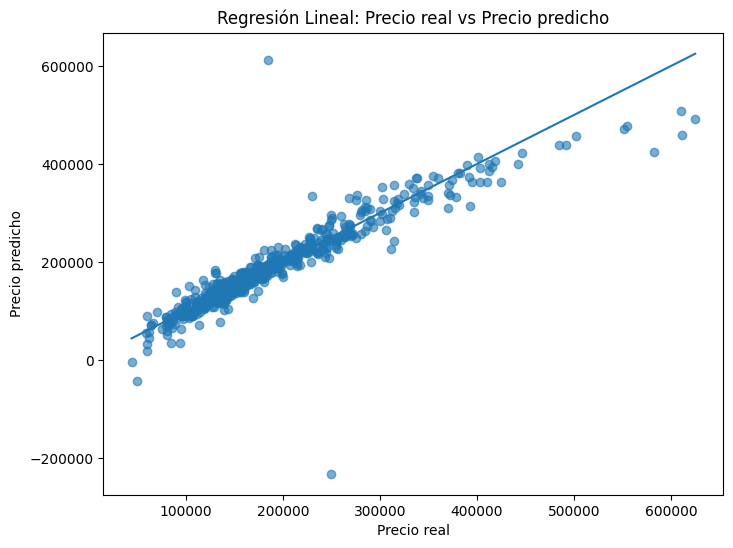

In [15]:
# 17. Visualizar valores reales vs predichos para evaluar gráficamente el desempeño del modelo.
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Lineal: Precio real vs Precio predicho")

# Línea de referencia perfecta.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.show()

In [16]:
# 18. Mostrar algunos ejemplos comparando precios reales y predichos.
results = pd.DataFrame({
    "Precio real": y_test.values,
    "Precio predicho": y_pred
})

print("\nPrimeras predicciones:")
print(results.head(10))


Primeras predicciones:
   Precio real  Precio predicho
0       161000    156883.333849
1       116000    109627.931272
2       196500    197800.273263
3       123600    133490.746270
4       126000    131977.304751
5       174190    193218.302540
6       200000    168682.323391
7       148500    146011.071983
8        88750     98061.024090
9       409900    363249.006338
